In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [12]:
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from scipy.stats import randint, uniform
import time


In [2]:
data = pd.read_csv('/Users/nheechan/Desktop/DS capstone/water-quality-england/data/England_dataset.csv')
data.head()

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,23.40,152.00,10.2,3.900,7.78,11.46,0.20,4.5,42.847368,Poor
1,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,21.30,102.00,10.2,3.430,7.78,8.30,0.20,4.5,43.496934,Poor
2,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,4.03,12.50,10.2,0.495,7.78,8.90,3.83,4.5,60.444542,Marginal
3,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.09,4.18,10.2,0.780,7.78,8.30,2.11,4.5,59.285522,Marginal
4,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.10,3.58,10.2,0.728,7.78,8.20,1.46,4.5,59.820608,Marginal


In [3]:
data2 = data.drop(columns=['Country', 'Area', 'Waterbody Type', 'Date'])
data2.head()

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,23.40,152.00,10.2,3.900,7.78,11.46,0.20,4.5,42.847368,Poor
1,21.30,102.00,10.2,3.430,7.78,8.30,0.20,4.5,43.496934,Poor
2,4.03,12.50,10.2,0.495,7.78,8.90,3.83,4.5,60.444542,Marginal
3,5.09,4.18,10.2,0.780,7.78,8.30,2.11,4.5,59.285522,Marginal
4,5.10,3.58,10.2,0.728,7.78,8.20,1.46,4.5,59.820608,Marginal


In [4]:
X = data2.drop(columns=['CCME_Values', 'CCME_WQI'])
y = data2['CCME_Values']

print(X.shape)
print(y.shape)

(2129198, 8)
(2129198,)


In [5]:
## 60% for training, 20% for validation, and 20% for testing
## Hold out 20% for testing
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Split the remaining 80% into training and validation sets (60% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Validation set size: {X_val.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 1277518 samples
Validation set size: 425840 samples
Test set size: 425840 samples


In [6]:
combined = pd.concat([X_train, X_val])
n_duplicates = combined.duplicated().sum()
print(f"Duplicate rows across train+val: {n_duplicates}")
# Also check what fraction of val rows are exact duplicates of train rows
val_in_train = X_val.merge(X_train.drop_duplicates(), how='inner')
print(f"Val rows that are exact duplicates of train rows: {len(val_in_train)}")
print(f"As % of val set: {len(val_in_train)/len(X_val)*100:.1f}%")

Duplicate rows across train+val: 34244
Val rows that are exact duplicates of train rows: 10627
As % of val set: 2.5%


In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

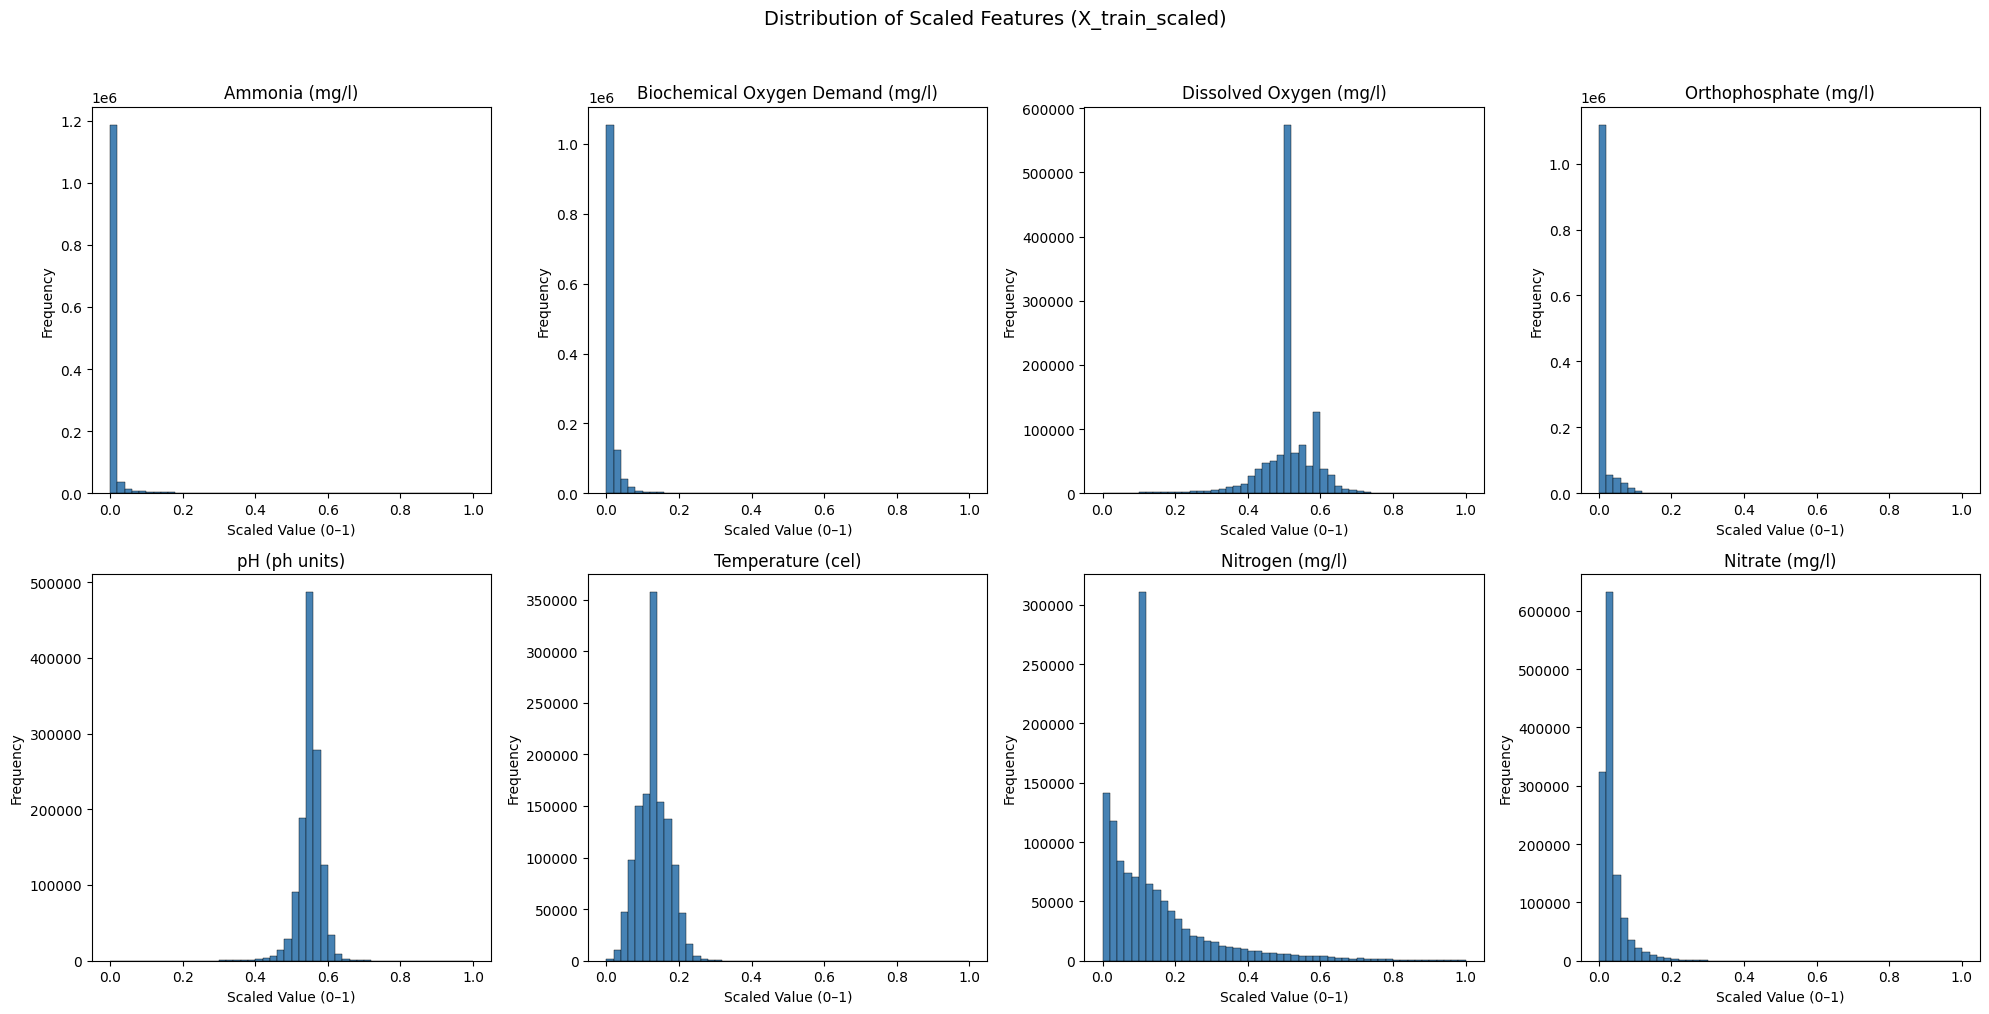

In [8]:
feature_cols = X_train.columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(X_train_scaled[:, i], bins=50, color='steelblue', edgecolor='black', linewidth=0.3)
    axes[i].set_title(col)
    axes[i].set_xlabel('Scaled Value (0–1)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Scaled Features (X_train_scaled)', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig('../results/feature_distributions_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

## Random Forest

### Baseline

In [9]:
from sklearn.ensemble import RandomForestRegressor

In [10]:
rf_reg = RandomForestRegressor(
    n_estimators=100,        # number of trees
    max_features=1/3,        # fraction of features considered at each split
    oob_score=True,          # enables out-of-bag evaluation
    random_state=42,
    n_jobs=-1                 # use all available CPU cores
)

## Train the model and evaluate on validation set
rf_reg.fit(X_train_scaled, y_train)
y_val_pred_rf = rf_reg.predict(X_val_scaled)

In [11]:
## Validation metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2 = r2_score(y_val, y_val_pred_rf)
mae = mean_absolute_error(y_val, y_val_pred_rf)

print(f"Baseline OOB score: {rf_reg.oob_score_:.3f}")
print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation R²: {r2:.4f}')
print(f'Validation MAE: {mae:.4f}')

Baseline OOB score: 0.999
Validation RMSE: 0.4011
Validation R²: 0.9995
Validation MAE: 0.1713


Text(0.5, 1.0, 'Residuals vs Predicted (Baseline Random Forest)')

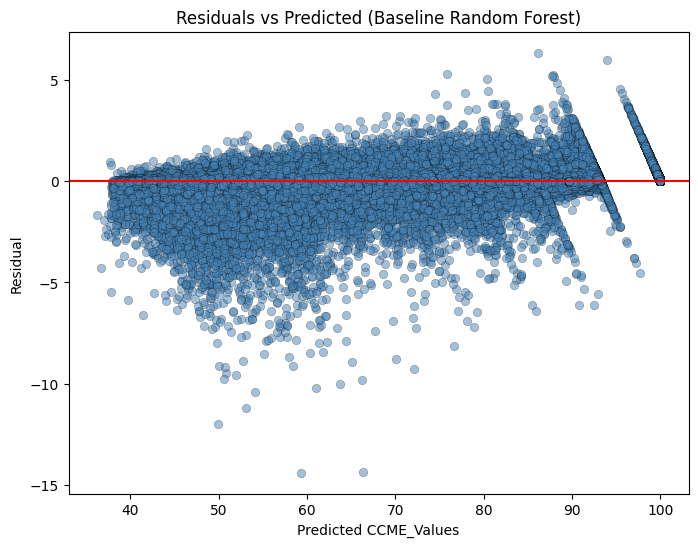

In [37]:
residuals_rf = y_val - y_val_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_rf, residuals_rf, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME_Values")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Baseline Random Forest)")

### RandomizedSearchCV

In [13]:
SEARCH_SAMPLE = 200_000
idx_rf = np.random.default_rng(42).choice(len(X_train_scaled), size=SEARCH_SAMPLE, replace=False)
X_rf_search = X_train_scaled[idx_rf]
y_rf_search = y_train.iloc[idx_rf].reset_index(drop=True)

rf_param_dist = {
    'n_estimators': randint(50, 300),       # more trees = more stable, diminishing returns past ~200
    'max_depth': [None, 10, 20, 30],        # None = fully grown; shallow trees underfit
    'min_samples_split': randint(2, 20),    # min samples to split a node; higher = more regularization
    'min_samples_leaf': randint(1, 10),     # min samples in a leaf; higher = smoother predictions
    'max_features': ['sqrt', 'log2', 0.3, 0.5],  # features per split; lower = more diverse trees
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=False),
    param_distributions=rf_param_dist,
    n_iter=20,              # number of random combos to try
    cv=3,                   # 3-fold CV inside the search
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True              # refit the best model on the full search sample when done
)

start = time.time()
rf_search.fit(X_rf_search, y_rf_search)
print(f"RF search time: {time.time() - start:.1f}s")
print("Best params:", rf_search.best_params_)
print(f"Best CV RMSE: {-rf_search.best_score_:.4f}")

# Confirm on held-out val set
y_val_pred_rf_tuned = rf_search.best_estimator_.predict(X_val_scaled)
print(f"Val R²: {r2_score(y_val, y_val_pred_rf_tuned):.4f}")
print(f"Val RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_rf_tuned)):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


python(37477) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37480) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37481) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37482) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37483) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37484) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37485) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37486) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37487) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END max_depth=30, max_features=0.3, min_samples_leaf=6, min_samples_split=3, n_estimators=137; total time=  32.1s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=6, min_samples_split=3, n_estimators=137; total time=  32.5s
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  32.8s
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  33.0s
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  33.2s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=13, n_estimators=107; total time=  28.5s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=6, min_samples_split=3, n_estimators=137; total time=  32.3s
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=8, min_samples_split=8, n_estimators=171; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_s

Improvement: 
* Val RMSE baseline (0.4011) > Val RMSE tuned (0.3052) 
* CV RMSE (0.3464) > Val RMSE (0.3052) — the model does better on your actual val set than on its internal CV folds
* R square slightly increases from 0.9995 to 0.9097

Text(0.5, 1.0, 'Residuals vs Predicted (Tuned Random Forest)')

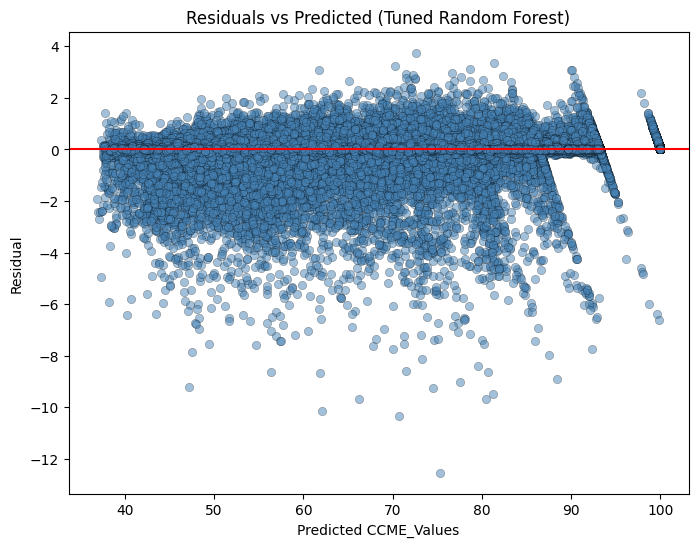

In [18]:
residuals_rf_tuned = y_val - y_val_pred_rf_tuned

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_rf_tuned, residuals_rf_tuned, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME_Values")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Tuned Random Forest)")

## SVR

### Baseline model

In [40]:
from sklearn.svm import SVR

In [41]:
SVR_SAMPLE = 50_000
idx = np.random.default_rng(42).choice(len(X_train_scaled), size=SVR_SAMPLE, replace=False)
X_svr_train = X_train_scaled[idx]
y_svr_train = y_train.iloc[idx]

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr.fit(X_svr_train, y_svr_train)
y_val_pred_svr = svr.predict(X_val_scaled)

In [42]:
rmse_svr = np.sqrt(mean_squared_error(y_val, y_val_pred_svr))
r2_svr = r2_score(y_val, y_val_pred_svr)
mae_svr = mean_absolute_error(y_val, y_val_pred_svr)

print(f'SVR Validation RMSE: {rmse_svr:.4f}')
print(f'SVR Validation R²: {r2_svr:.4f}')
print(f'SVR Validation MAE: {mae_svr:.4f}')

SVR Validation RMSE: 9.5115
SVR Validation R²: 0.7247
SVR Validation MAE: 7.1065


Text(0.5, 1.0, 'Residuals vs Predicted (Baseline SVR)')

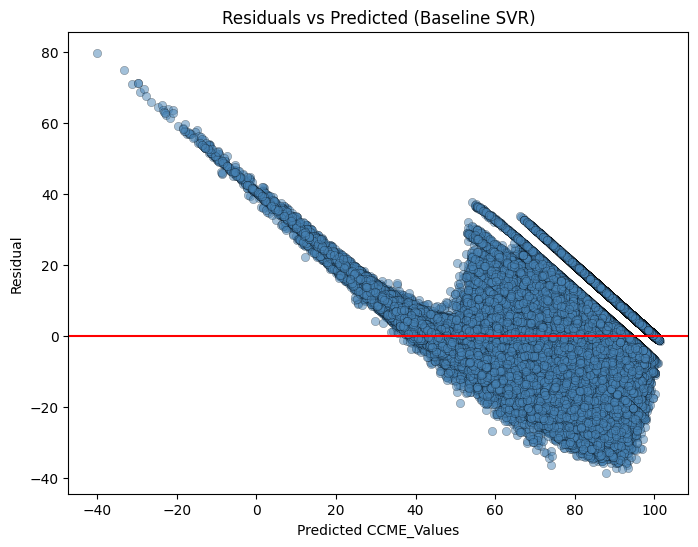

In [43]:
residuals_svr = y_val - y_val_pred_svr

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_svr, residuals_svr, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME_Values")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Baseline SVR)")

- C=1.0 is quite small => allow large margins to tolerate too much errors. Might need to modify this during hyperparameter tuning
- Because I only trained the model on 50K samples but still try to fit it on the validation set of the original size (~400K rows) => the model performs poorly in generalize the results to a much larger pool of data => RMSE is oddly large (outside the bound of 0 to 1)
- RMSE and MAE are oddly large
- **Have to go back to this later**

## XGboost

### Baseline model

In [14]:
import xgboost as xgb
from xgboost import XGBRegressor

In [15]:
import time
start_time = time.time()

xgb_base = XGBRegressor(n_jobs=-1, random_state=42)
xgb_base.fit(X_train_scaled, y_train)
print("Training time for XGBoost baseline: ", time.time() - start_time)
y_val_pred_xgb = xgb_base.predict(X_val_scaled)

Training time for XGBoost baseline:  1.7584137916564941


In [16]:
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
r2_xgb = r2_score(y_val, y_val_pred_xgb)
mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)

print(f'XGBoost Validation RMSE: {rmse_xgb:.4f}')
print(f'XGBoost Validation R²: {r2_xgb:.4f}')
print(f'XGBoost Validation MAE: {mae_xgb:.4f}')

XGBoost Validation RMSE: 0.5563
XGBoost Validation R²: 0.9991
XGBoost Validation MAE: 0.1957


Text(0.5, 1.0, 'Residuals vs Predicted (Baseline XGBoost)')

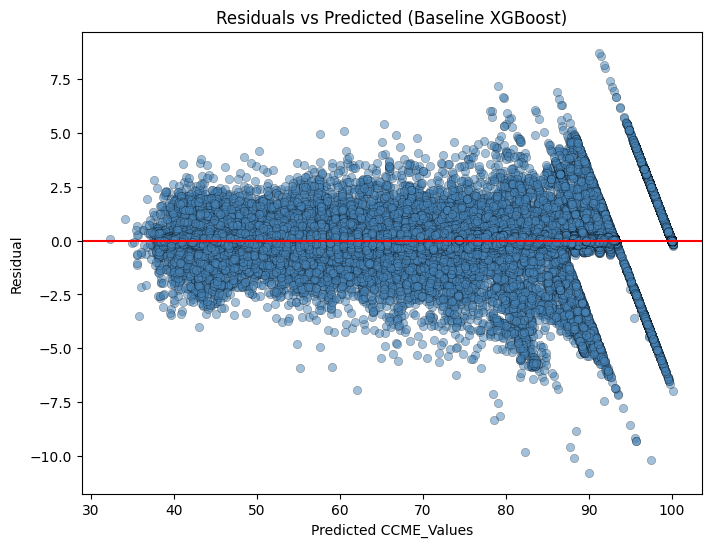

In [38]:
residuals_xgb = y_val - y_val_pred_xgb

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_xgb, residuals_xgb, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME_Values")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Baseline XGBoost)")

In [15]:

early_stopping_xgb = xgb.XGBRegressor(early_stopping_rounds=5, n_jobs=-1, random_state=42)
start_time = time.time()
early_stopping_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)
print("Training time for XGBoost with early stopping: ", time.time() - start_time)
y_val_pred_early_xgb = early_stopping_xgb.predict(X_val_scaled)
print("Early stopping model -")
print("Stopped on iteration: ", early_stopping_xgb.best_iteration)

Training time for XGBoost with early stopping:  2.053521156311035
Early stopping model -
Stopped on iteration:  99


In [16]:
rmse_xgb_es = np.sqrt(mean_squared_error(y_val, y_val_pred_early_xgb))
r2_xgb_es = r2_score(y_val, y_val_pred_early_xgb)
mae_xgb_es = mean_absolute_error(y_val, y_val_pred_early_xgb)
print(f'Early Stopping XGBoost Validation RMSE: {rmse_xgb_es:.4f}')
print(f'Early Stopping XGBoost Validation R²: {r2_xgb_es:.4f}')
print(f'Early Stopping XGBoost Validation MAE: {mae_xgb_es:.4f}')

Early Stopping XGBoost Validation RMSE: 0.5563
Early Stopping XGBoost Validation R²: 0.9991
Early Stopping XGBoost Validation MAE: 0.1957


### RandomizedSearchCV

In [17]:
# XGBoost is fast enough to run on the full training set
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),           # deeper = more complex; XGB is sensitive to this
    'learning_rate': uniform(0.01, 0.29),  # smaller = need more trees; larger = faster but unstable
    'subsample': uniform(0.6, 0.4),        # fraction of rows per tree; reduces overfitting
    'colsample_bytree': uniform(0.6, 0.4), # fraction of features per tree
    'min_child_weight': randint(1, 10),    # min sum of instance weight in a leaf
    'reg_alpha': uniform(0, 1),            # L1 regularization
    'reg_lambda': uniform(0.5, 2),         # L2 regularization
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

start = time.time()
xgb_search.fit(X_train_scaled, y_train)
print(f"XGB search time: {time.time() - start:.1f}s")
print("Best params:", xgb_search.best_params_)
print(f"Best CV RMSE: {-xgb_search.best_score_:.4f}")

y_val_pred_xgb_tuned = xgb_search.best_estimator_.predict(X_val_scaled)
print(f"Val R²: {r2_score(y_val, y_val_pred_xgb_tuned):.4f}")
print(f"Val RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_tuned)):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


python(37729) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37730) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37731) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37732) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37733) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37734) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37735) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37736) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=288, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time=  25.9s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=288, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time=  26.3s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=288, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time=  26.7s
[CV] END colsample_bytree=0.7836995567863468, learning_rate=0.10677549723031632, max_depth=5, min_child_weight=6, n_estimators=408, reg_alpha=0.9699098521619943, reg_lambda=2.1648852816008435, subsample=0.6849356442713105; total time=  36.8s
[CV] END colsample_bytree=0.7836995567

## LightGBM

In [19]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

In [20]:
lgbm_baseline = LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_baseline.fit(X_train_scaled, y_train)
y_val_pred_lgbm = lgbm_baseline.predict(X_val_scaled)

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [20]:
rmse_lgbm = np.sqrt(mean_squared_error(y_val, y_val_pred_lgbm))
r2_lgbm = r2_score(y_val, y_val_pred_lgbm)
mae_lgbm = mean_absolute_error(y_val, y_val_pred_lgbm)

print(f'LightGBM Validation RMSE: {rmse_lgbm:.4f}')
print(f'LightGBM Validation R²: {r2_lgbm:.4f}')
print(f'LightGBM Validation MAE: {mae_lgbm:.4f}')

LightGBM Validation RMSE: 0.2294
LightGBM Validation R²: 0.9998
LightGBM Validation MAE: 0.1117


Text(0.5, 1.0, 'Residuals vs Predicted (Baseline LightGBM)')

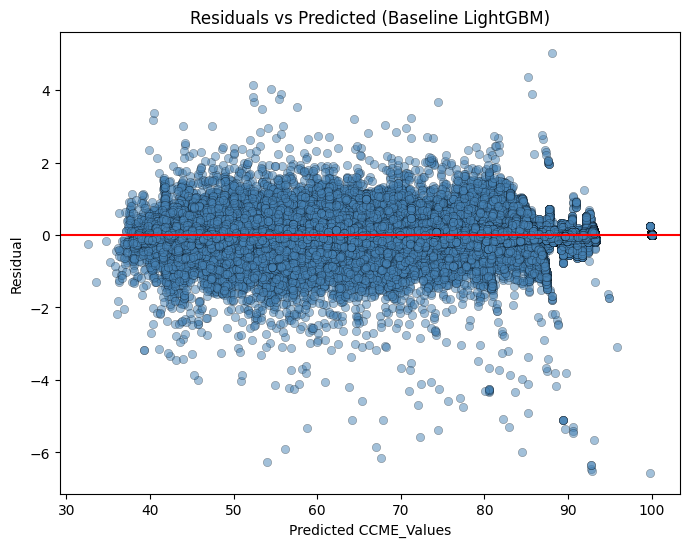

In [39]:
residuals_lgbm = y_val - y_val_pred_lgbm

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_lgbm, residuals_lgbm, alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME_Values")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Baseline LightGBM)")

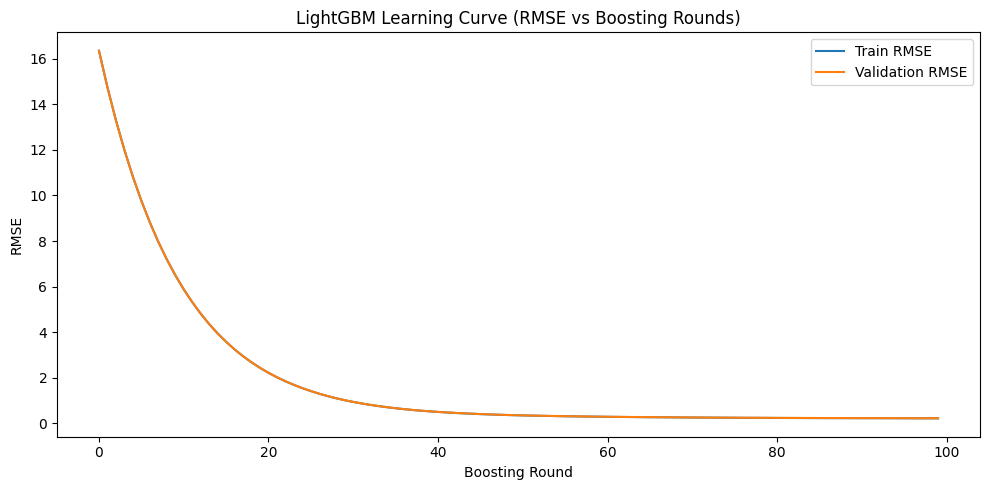

In [ ]:
evals_result = {}

lgbm_baseline.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    eval_names=['train', 'val'],
    callbacks=[lgb.record_evaluation(evals_result)]
)

train_rmse = np.sqrt(evals_result['train']['l2'])
val_rmse   = np.sqrt(evals_result['val']['l2'])

plt.figure(figsize=(10, 5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('LightGBM Learning Curve (RMSE vs Boosting Rounds)')
plt.legend()
plt.tight_layout()
# plt.savefig('../results/lgbm_learning_curve.png', dpi=150)
plt.show()

The train RMSE and validation RMSE overlap

### RandomizedSearchCV

In [21]:
lgbm_param_dist = {
    'n_estimators': randint(100, 500),
    'num_leaves': randint(20, 150),        # max leaves per tree; key LightGBM param (more = complex)
    'learning_rate': uniform(0.01, 0.29),
    'max_depth': randint(3, 12),
    'min_child_samples': randint(10, 100), # min data in a leaf; higher = more regularization
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2),
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

start = time.time()
lgbm_search.fit(X_train_scaled, y_train)
print(f"LGBM search time: {time.time() - start:.1f}s")
print("Best params:", lgbm_search.best_params_)
print(f"Best CV RMSE: {-lgbm_search.best_score_:.4f}")

y_val_pred_lgbm_tuned = lgbm_search.best_estimator_.predict(X_val_scaled)
print(f"Val R²: {r2_score(y_val, y_val_pred_lgbm_tuned):.4f}")
print(f"Val RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_lgbm_tuned)):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.996884623716487, learning_rate=0.18906963779203778, max_depth=8, min_child_samples=98, n_estimators=148, num_leaves=78, reg_alpha=0.3998609717152555, reg_lambda=0.09333132642723085, subsample=0.9895022075365837; total time=  18.6s


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.996884623716487, learning_rate=0.18906963779203778, max_depth=8, min_child_samples=98, n_estimators=148, num_leaves=78, reg_alpha=0.3998609717152555, reg_lambda=0.09333132642723085, subsample=0.9895022075365837; total time=  19.9s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=10, min_child_samples=70, n_estimators=120, num_leaves=122, reg_alpha=0.44583275285359114, reg_lambda=0.19994983163600577, subsample=0.7836995567863468; total time=  24.6s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=10, min_child_samples=70, n_estimators=120, num_leaves=122, reg_alpha=0.44583275285359114, reg_lambda=0.19994983163600577, subsample=0.7836995567863468; total time=  24.8s


...

[CV] END colsample_bytree=0.794696861183782, learning_rate=0.27276864843838067, max_depth=4, min_child_samples=30, n_estimators=385, num_leaves=116, reg_alpha=0.5769038846263591, reg_lambda=0.9850353876377278, subsample=0.6780971951192178; total time=  23.0s


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.888980846104602, learning_rate=0.09142398510784817, max_depth=5, min_child_samples=73, n_estimators=148, num_leaves=36, reg_alpha=0.994550510797341, reg_lambda=0.9398890279818859, subsample=0.7118241367187035; total time=   8.8s
[CV] END colsample_bytree=0.794696861183782, learning_rate=0.27276864843838067, max_depth=4, min_child_samples=30, n_estimators=385, num_leaves=116, reg_alpha=0.5769038846263591, reg_lambda=0.9850353876377278, subsample=0.6780971951192178; total time=  17.5s
[CV] END colsample_bytree=0.888980846104602, learning_rate=0.09142398510784817, max_depth=5, min_child_samples=73, n_estimators=148, num_leaves=36, reg_alpha=0.994550510797341, reg_lambda=0.9398890279818859, subsample=0.7118241367187035; total time=   9.2s
LGBM search time: 302.9s
Best params: {'colsample_bytree': np.float64(0.943343521925488), 'learning_rate': np.float64(0.10452808250854656), 'max_depth': 6, 'min_child_samples': 28, 'n_estimators': 445, 'num_leaves': 115, 'reg_a

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Val R²: 0.9999
Val RMSE: 0.1355


## Run the models on the test set

In [22]:
# Test set evaluation
models = {
    'Random Forest': rf_search.best_estimator_,
    'XGBoost':       xgb_search.best_estimator_,
    'LightGBM':      lgbm_search.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{name}")
    print(f"  Test R²:   {r2_score(y_test, y_pred):.4f}")
    print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
    print()

Random Forest
  Test R²:   0.9997
  Test RMSE: 0.3046
  Test MAE:  0.0779

XGBoost
  Test R²:   0.9991
  Test RMSE: 0.5482
  Test MAE:  0.2046



/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM
  Test R²:   0.9999
  Test RMSE: 0.1375
  Test MAE:  0.0591



/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


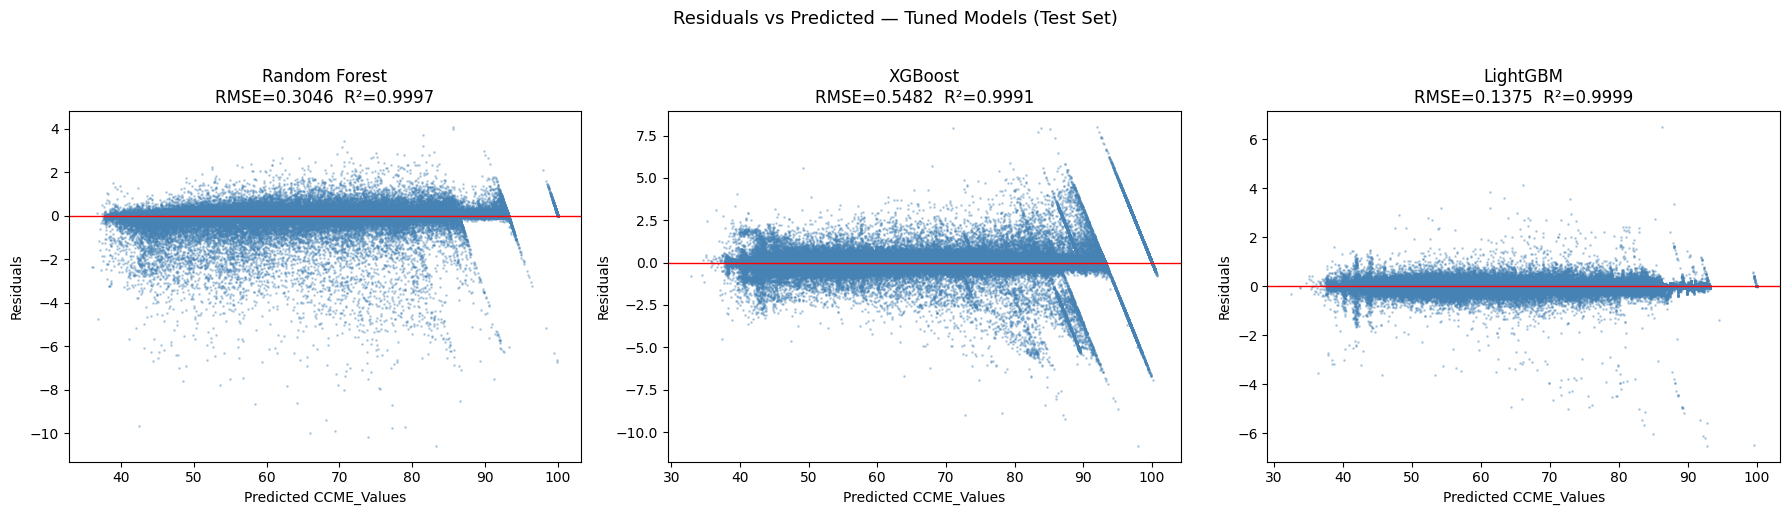

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Random Forest': rf_search.best_estimator_,
    'XGBoost':       xgb_search.best_estimator_,
    'LightGBM':      lgbm_search.best_estimator_,
}

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, s=1, color='steelblue')
    ax.axhline(0, color='red', linewidth=1)
    ax.set_xlabel('Predicted CCME_Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name}\nRMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.4f}  R²={r2_score(y_test, y_pred):.4f}')

plt.suptitle('Residuals vs Predicted — Tuned Models (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('../results/residuals_vs_predicted_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RF   predictions > 100: 0
XGB  predictions > 100: 44755
LGBM predictions > 100: 74606

Top 15 most frequent y_true values in range 85-100:
CCME_Values
100.000000    89407
89.633936     49671
93.130147      1364
91.406465      1234
91.874482      1133
90.906795      1106
92.945369      1099
90.385541      1005
92.661197       997
93.178952       981
93.184927       965
93.194984       952
89.850462       949
92.298013       944
93.192959       942
Name: count, dtype: int64


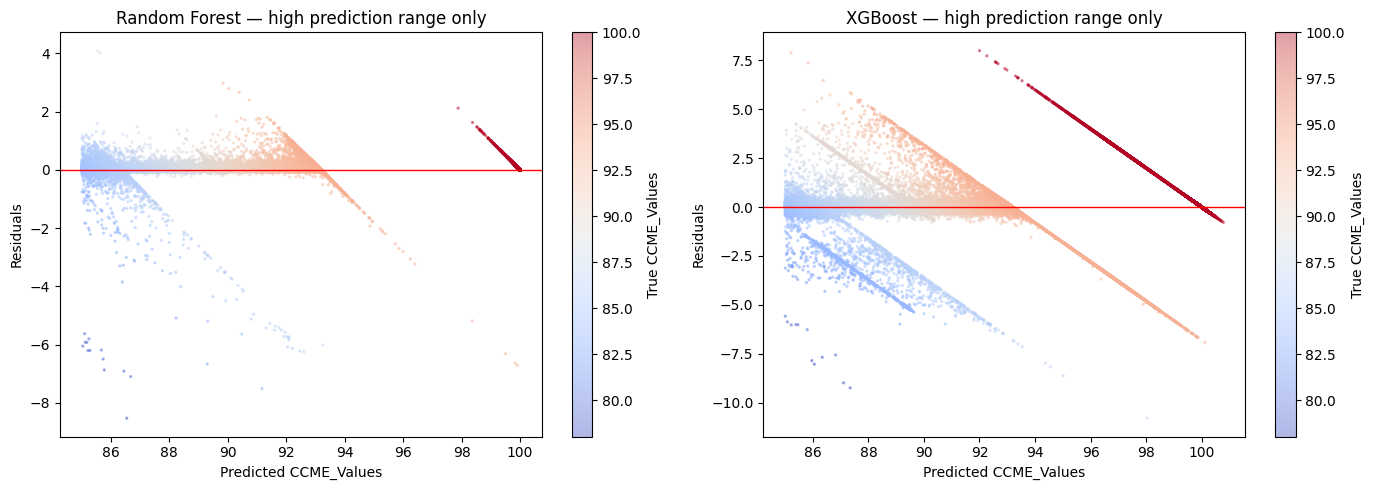

In [24]:
# 1. Check if predictions exceed 100 (outside the valid CCME range)
y_pred_rf  = rf_search.best_estimator_.predict(X_test_scaled)
y_pred_xgb = xgb_search.best_estimator_.predict(X_test_scaled)
y_pred_lgb = lgbm_search.best_estimator_.predict(X_test_scaled)

print("RF   predictions > 100:", (y_pred_rf  > 100).sum())
print("XGB  predictions > 100:", (y_pred_xgb > 100).sum())
print("LGBM predictions > 100:", (y_pred_lgb > 100).sum())

# 2. Check if y_true clusters at specific values in the 85-100 range
high_mask = y_test >= 85
print("\nTop 15 most frequent y_true values in range 85-100:")
print(y_test[high_mask].value_counts().head(15))

# 3. Visualise — each streak = one horizontal cluster of true values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, {'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}.items()):
    mask = y_pred >= 85
    residuals = y_test - y_pred
    sc = ax.scatter(y_pred[mask], residuals[mask], c=y_test[mask],
                    cmap='coolwarm', alpha=0.4, s=2)
    plt.colorbar(sc, ax=ax, label='True CCME_Values')
    ax.axhline(0, color='red', linewidth=1)
    ax.set_xlabel('Predicted CCME_Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} — high prediction range only')

plt.tight_layout()
plt.show()

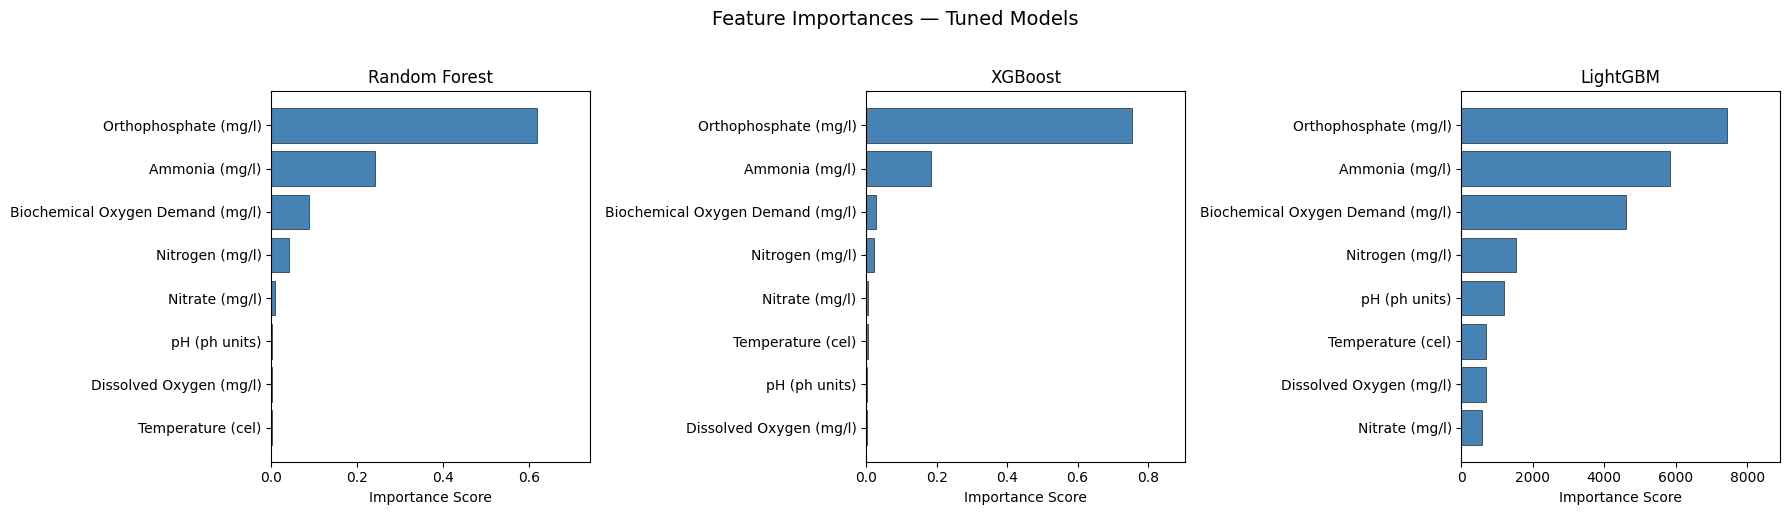

In [26]:
feature_names = X_train.columns.tolist()

importances = {
    'Random Forest': rf_search.best_estimator_.feature_importances_,
    'XGBoost':       xgb_search.best_estimator_.feature_importances_,
    'LightGBM':      lgbm_search.best_estimator_.feature_importances_,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, imp) in zip(axes, importances.items()):
    # sort descending
    sorted_idx = np.argsort(imp)
    sorted_imp = imp[sorted_idx]
    sorted_features = [feature_names[i] for i in sorted_idx]

    bars = ax.barh(sorted_features, sorted_imp, color='steelblue', edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Importance Score')
    ax.set_title(name)
    ax.set_xlim(0, max(imp) * 1.2)

plt.suptitle('Feature Importances — Tuned Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
